In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import snapatac2 as snap
import pickle
import sys
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
import os
import glob

from matplotlib.colors import Normalize
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage
import warnings

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

### 7b Program 38 attribution

In [2]:
def normalize_attr(gene_mtx):
    
    norm_means = gene_mtx.div(gene_mtx.abs().sum(axis = 1), axis = 0)
    z_prgm_attrs = (norm_means - norm_means.mean()) / norm_means.std()
    return z_prgm_attrs

program_features = pd.read_csv("/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/260414_gex_raw_100_prgm_features.csv")
gene_mtx_raw = pd.read_parquet("/data1/normantm/eli/T7/202511_RPE1_dg50/models/genelevel_clustered/genelevel_attr_pairs_ig.parquet").set_index(['gene', 'pair'])
gene_mtx = normalize_attr(gene_mtx_raw)

resid = pd.read_csv("/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/260506_tvals_expectation_fit.csv", index_col = 0)
programs_diff = pd.read_csv('/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/260414_gex_raw_100_prgm_features.csv', index_col = 0).query("feature.isin(@resid.columns)")
programs_diff['weight'] = programs_diff.groupby('program_id').weight.transform(lambda x: x / x.sum())
dfs = []
for i in range(100):
    genes = programs_diff.query("program_id == @i").feature.tolist()
    weights = (programs_diff.query("program_id == @i").weight.tolist() / programs_diff.query("program_id == @i").weight.sum()).tolist()
    dfs.append(resid.filter(items = genes).mul(weights).sum(axis = 1).sort_values(ascending=False))
program_residuals = pd.concat(dfs, axis = 1).sort_index()
program_residuals = (program_residuals - program_residuals.mean()) / program_residuals.std()

cluster_names = pd.read_csv('/data1/normantm/eli/T7/202511_RPE1_dg50/models/genelevel_clustered/attr_motif_clusters.csv', index_col = 0)
cluster_names = dict(zip(cluster_names.key, cluster_names.new_name))

geometry = pd.read_csv('/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/3D_emb_geometry.csv', index_col = 0)
attr_genes = gene_mtx.index.get_level_values(0).unique().values
program_to_genes = program_features.groupby("program_id")["feature"].apply(set).to_dict()

gene_mtx.columns = gene_mtx.columns.map(lambda i: cluster_names.get(i, i))
gene_mtx_raw.columns = gene_mtx_raw.columns.map(lambda i: cluster_names.get(i, i))

def map_attribution(program, z_prgm = False, plot = False, figsize = (30,30), **cg_kwargs):

    prgm_genes = list(set(attr_genes).intersection(program_to_genes.get(program, set())))
    df_prgm = pd.DataFrame(0.0, index = gene_mtx.index.get_level_values(1).unique(), columns = gene_mtx_raw.columns)
    for g in prgm_genes:
        weight = program_features.query("program_id == @program and feature == @g").weight.item()
        amtx = gene_mtx_raw.loc[g] * weight if z_prgm else gene_mtx.loc[g] * weight
        df_prgm += amtx
    if z_prgm:
        df_prgm = normalize_attr(df_prgm)
    
    if plot:
        df_rows = pd.DataFrame(index = df_prgm.index).join(program_residuals[program]).rename({program: 'resid'}, axis = 1)
        df_rows = df_rows.join(geometry.dominant_tgt)
        mapper = dict(zip(np.sort(df_rows.dominant_tgt.unique()), sns.color_palette("husl", 50)))
        df_rows['dominant_tgt'] = df_rows.dominant_tgt.map(mapper)
        cmap = sns.color_palette("viridis", as_cmap = True)
        norm = Normalize(vmin = -2, vmax = 2)
        df_rows['resid'] = df_rows.resid.map(lambda x: cmap(norm(np.clip(x, -2, 2))))

        vmin = -6 if not z_prgm else -3
        vmax = 6 if not z_prgm else 3

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            df_rows.columns = ["", ""]
            cg = sns.clustermap(df_prgm, metric = 'correlation', method = 'average', cmap = 'RdBu_r', figsize = figsize, row_colors=df_rows, colors_ratio=0.01, center = 0, vmin = vmin, vmax = vmax, **cg_kwargs, dendrogram_ratio=[0.05, 0.05])
            cg.ax_row_colors.set_yticks([])

            # remove colorbar
            cg.cax.set_visible(False)

            # remove y-axis label/ticks on row color annotation
            cg.ax_row_colors.set_ylabel("")
            cg.ax_row_colors.set_yticks([])

            # remove x-axis ticks/labels below column dendrogram/heatmap
            cg.ax_heatmap.set_xticks([])
            cg.ax_heatmap.set_xlabel("")
            cg.ax_col_dendrogram.set_xticks([])
            cg.ax_col_dendrogram.set_yticks([])
                
        return cg, df_prgm

    return df_prgm  

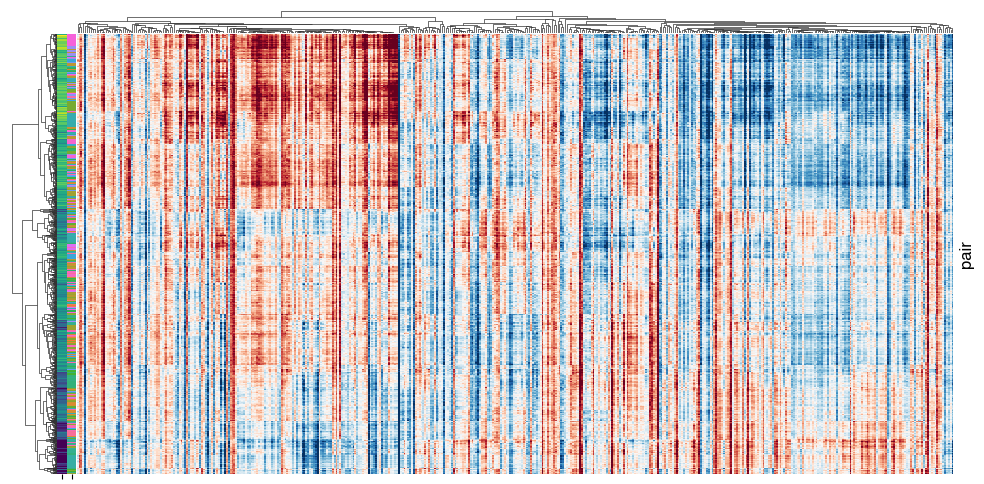

In [3]:
cg, df_prgm = map_attribution(38, z_prgm=False, figsize = (10,5), xticklabels = False, yticklabels = False, plot = True)
# plt.savefig('plots/p38_attr_mtx.png', dpi = 500)

### 7c constitutive and conditional regulators

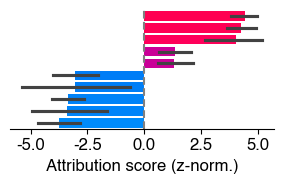

In [5]:
import matplotlib as mpl

sys.path.append('/data1/normantm/eli/software')
from colors import red_blue

highlight_features = ['EGR', 'CREB3L3',  'NFKB', 'CREB1', 'HSF', 'HD/2', 'RUNX', 'MYRF_res_acc', 'CUX/1', 'SREBF1']
df_constitutive = df_prgm[highlight_features].reset_index().melt(id_vars = 'pair', var_name = 'feature', value_name = 'attr_score')

plt.figure(figsize = (3,2))
ax = sns.barplot(df_constitutive, y = 'feature', x = 'attr_score', order = highlight_features, errorbar = ('pi', 50))

means = (
    df_constitutive.groupby('feature')['attr_score']
    .mean()
    .reindex(highlight_features)
)

norm = mpl.colors.TwoSlopeNorm(vmin=means.min(), vcenter=0, vmax=means.max())

for bar, val in zip(ax.patches, means):
    bar.set_facecolor(red_blue(norm(val)))

plt.axvline(x = 0, linestyle = '--', color = 'grey')
plt.xlabel('Attribution score (z-norm.)')

ax.set_ylabel('')
ax.set_xlabel(ax.get_xlabel())
ax.tick_params(axis='y', left=False, labelleft=False)
sns.despine(ax=ax, left=True, bottom=False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
# plt.savefig('plots/7b_constitutive.pdf')

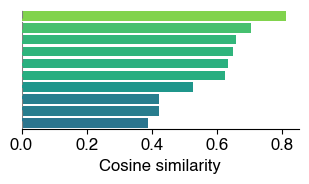

In [8]:
import matplotlib as mpl

df_cosine = (
    df_prgm.apply(lambda x: np.dot(x, program_residuals[38]) / (np.linalg.norm(x) * np.linalg.norm(program_residuals[38])))
    .sort_values(ascending=False)
    .to_frame(name='cosine')
)

highlight_features = ['SOX/4', 'OSR', 'BARX2', 'GATA2_res_acc', 'MYC', 'SOX18_res_acc', 'CUX/3', 'EBOX/1', 'AP1/1', 'IRF/1']

plt.figure(figsize = (3.25,2))
ax = sns.barplot(df_cosine.reset_index(), y='index', x='cosine', order=highlight_features)
means = df_cosine.loc[highlight_features, 'cosine']

norm = mpl.colors.Normalize(vmin=0, vmax=1)
cmap = sns.color_palette("viridis", as_cmap=True)

for bar, val in zip(ax.patches, means):
    bar.set_facecolor(cmap(norm(val)))

plt.axvline(x=0, linestyle='--', color='grey')
plt.xlabel("Cosine similarity")
ax.set_ylabel('')
ax.tick_params(axis='y', left=False, labelleft=False)
sns.despine(ax=ax, left=True, bottom=False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
# plt.savefig('plots/7b_conditional.pdf')
plt.show()

In [10]:
df_cosine.query("index.str.contains('SMAD')")

,cosine
SMAD/2,0.462533
SMAD/1,-0.415966


### 7d attribution comparison to RPE1 TFome-wide CRISPRa

In [11]:
from tqdm import trange
program_mtx = pd.DataFrame(index = list(range(100)), columns = df_prgm.columns)
for i in trange(100):
    program_mtx.loc[i] = map_attribution(i, z_prgm = False, plot = False).mean()

100%|██████████| 100/100 [01:11<00:00,  1.40it/s]


In [12]:
cluster_names = pd.read_csv('/data1/normantm/eli/T7/202511_RPE1_dg50/models/genelevel_clustered/attr_motif_clusters.csv', index_col = 0)
cluster_names = dict(zip(cluster_names.key, cluster_names.new_name))
clusters = pd.read_csv('/data1/normantm/tmn/JASPAR_vertebrates_CORE_flat_metadata.tsv', sep='\t')
clusters['motif_name'] = clusters.matrix_id + '.' + clusters.name
cluster_dict = clusters.groupby('subcluster_ncor_0.7').motif_name.agg(list).to_dict()
cluster_name_to_tfs = {v: cluster_dict[k] for k, v in cluster_names.items()}
tf_to_cluster_name = {i.split('.')[-1].upper(): k for k, v in cluster_name_to_tfs.items() for i in v}

meanpop = sc.read('/data1/normantm/eli/scratch/RPE1_CRISPRa_mean_pop.h5ad')
s4 = pd.read_excel('/data1/normantm/eli/scratch/TableS4_guides.xlsx')
meanpop.obs = meanpop.obs.join(s4.set_index('guide_identity')[['bad_seed', 'activation_expression_rpe1', 'final_tf_library']])
meanpop.obs['bad_seed'] = meanpop.obs.bad_seed.astype(bool)
meanpop.obs['final_tf_library'] = meanpop.obs.final_tf_library.fillna(False).astype(bool)

meanpop = meanpop[(meanpop.obs.final_tf_library) & (meanpop.obs.activation_expression_rpe1 != 'dropout')].copy()

/tmp/ipykernel_3129888/2538182439.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  meanpop.obs['final_tf_library'] = meanpop.obs.final_tf_library.fillna(False).astype(bool)


In [14]:
df_scores = pd.DataFrame(index = meanpop.obs.index, columns = list(range(100)))
overlap_genes = []
for i in range(100):
    common_genes = [g for g in program_features.query("program_id == @i").feature.unique() if g in meanpop.var_names and g in attr_genes]
    weights = program_features.query("program_id == @i").set_index('feature').loc[common_genes].weight.values
    df_scores[i] = meanpop.to_df()[common_genes].mul(weights).sum(axis = 1)
    overlap_genes.append(common_genes)

df_scores['tf_name'] = df_scores.index.map(lambda i: i.split('_')[0])
df_scores['tf_cluster'] = df_scores.tf_name.map(lambda i: tf_to_cluster_name.get(i, np.nan))
program_mtx.columns = program_mtx.columns.map(lambda i: cluster_names.get(i, i))

df_attrs = pd.DataFrame(index=df_scores.index, columns = list(range(100)))
for i in range(100):
    df_attrs.loc[:, i] = df_scores.tf_cluster.map(lambda t: np.mean(np.atleast_1d(program_mtx.loc[i, t])) if t in program_mtx.columns else np.nan)

df_scores_by_name = df_scores.drop(['tf_name', 'tf_cluster'], axis = 1).dropna().copy().reset_index().melt(id_vars = 'guide_identity', var_name = 'prgm', value_name = 'program_score')
df_scores_by_name['tf_name'] = df_scores_by_name.guide_identity.map(lambda i: i.split('_')[0])
program_mtx_melted = program_mtx.reset_index().melt(id_vars = 'index', var_name = 'feature', value_name = 'attr_score').rename({'index': 'program'}, axis = 1)

/tmp/ipykernel_3129888/1204364683.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_scores['tf_name'] = df_scores.index.map(lambda i: i.split('_')[0])
/tmp/ipykernel_3129888/1204364683.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_scores['tf_cluster'] = df_scores.tf_name.map(lambda i: tf_to_cluster_name.get(i, np.nan))


In [15]:
def cluster_to_tfs(cluster):
    if cluster in cluster_name_to_tfs:
        return [t.split('.')[-1].upper() for t in cluster_name_to_tfs[cluster]]
    if cluster.endswith('res_acc'):
        return [cluster.split('_')[0]]
    return None

cluster_tfs_map = {c: cluster_to_tfs(c) for c in program_mtx_melted['feature'].unique()}

np.random.seed(42)
program_mtx_shuffle = program_mtx_melted.copy()
program_mtx_shuffle['feature'] = program_mtx_shuffle.groupby('program').feature.transform(np.random.permutation)

def score_program_mtx(program_mtx_melted, shuffle=False, random_state=42):

    df = program_mtx_melted.copy()
    df['tfs'] = df['feature'].map(cluster_tfs_map)
    df['row_id'] = df.index

    if shuffle:
        rng = np.random.default_rng(random_state)
        tf_pool = df_scores_by_name['tf_name'].unique()

        shuffled_map = {
            cluster: rng.choice(tf_pool, size=len(tfs), replace=False)
            for cluster, tfs in cluster_tfs_map.items()
            if tfs is not None
        }
        df['tfs'] = df['feature'].map(shuffled_map)

    valid = df[df['tfs'].notna()]
    long = valid.explode('tfs').rename(columns={'tfs': 'tf_name'})

    merged = long.merge(
        df_scores_by_name[['prgm', 'tf_name', 'program_score']],
        left_on=['program', 'tf_name'],
        right_on=['prgm', 'tf_name'],
        how='inner'
    )

    mean_scores = merged.groupby('row_id')['program_score'].mean()
    pos_pick = merged.loc[merged.groupby('row_id')['program_score'].idxmax()].set_index('row_id')
    neg_pick = merged.loc[merged.groupby('row_id')['program_score'].idxmin()].set_index('row_id')

    result = pd.DataFrame(index=df.index, columns=['score', 'top_regulator', 'mean_prgm_score'])
    pos_rows, neg_rows, zero_rows = df['attr_score'] > 0, df['attr_score'] < 0, df['attr_score'] == 0
    result.loc[pos_rows, ['score', 'top_regulator']] = pos_pick.reindex(df.index[pos_rows])[['program_score', 'tf_name']].values
    result.loc[pos_rows, 'mean_prgm_score'] = mean_scores.reindex(df.index[pos_rows]).values
    result.loc[neg_rows, ['score', 'top_regulator']] = neg_pick.reindex(df.index[neg_rows])[['program_score', 'tf_name']].values
    result.loc[neg_rows, 'mean_prgm_score'] = mean_scores.reindex(df.index[neg_rows]).values
    result.loc[zero_rows, 'score'] = mean_scores.reindex(df.index[zero_rows]).values
    result.loc[zero_rows, 'top_regulator'] = 'no_attr_score'

    df[['score', 'top_regulator', 'mean_prgm_score']] = result
    return df

In [16]:
program_mtx_melted = score_program_mtx(program_mtx_melted, shuffle = False)
program_mtx_shuffle = score_program_mtx(program_mtx_shuffle, shuffle = False)

program_mtx_plot = program_mtx_melted.dropna().copy()
program_mtx_plot['concordant'] = np.sign(program_mtx_plot.attr_score) == np.sign(program_mtx_plot.score)
program_mtx_plot['score'] = np.clip(program_mtx_plot.score, -2, 2)
program_mtx_plot['abs_score'] = program_mtx_plot.score.abs()

program_mtx_shuffle_plot = program_mtx_shuffle.dropna().copy()
program_mtx_shuffle_plot['concordant'] = np.sign(program_mtx_shuffle_plot.attr_score) == np.sign(program_mtx_shuffle_plot.score)
program_mtx_shuffle_plot['score'] = np.clip(program_mtx_shuffle_plot.score, -2, 2)
program_mtx_shuffle_plot['abs_score'] = program_mtx_shuffle_plot.score.abs()

In [17]:
program_mtx_plot.query("(attr_score < -1 or attr_score > 1) and (score > 0.5 or score < -0.5) and concordant").program.nunique()

63

2026-10-06 12:22:33 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-10-06 12:22:33 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-10-06 12:22:33 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-10-06 12:22:33 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


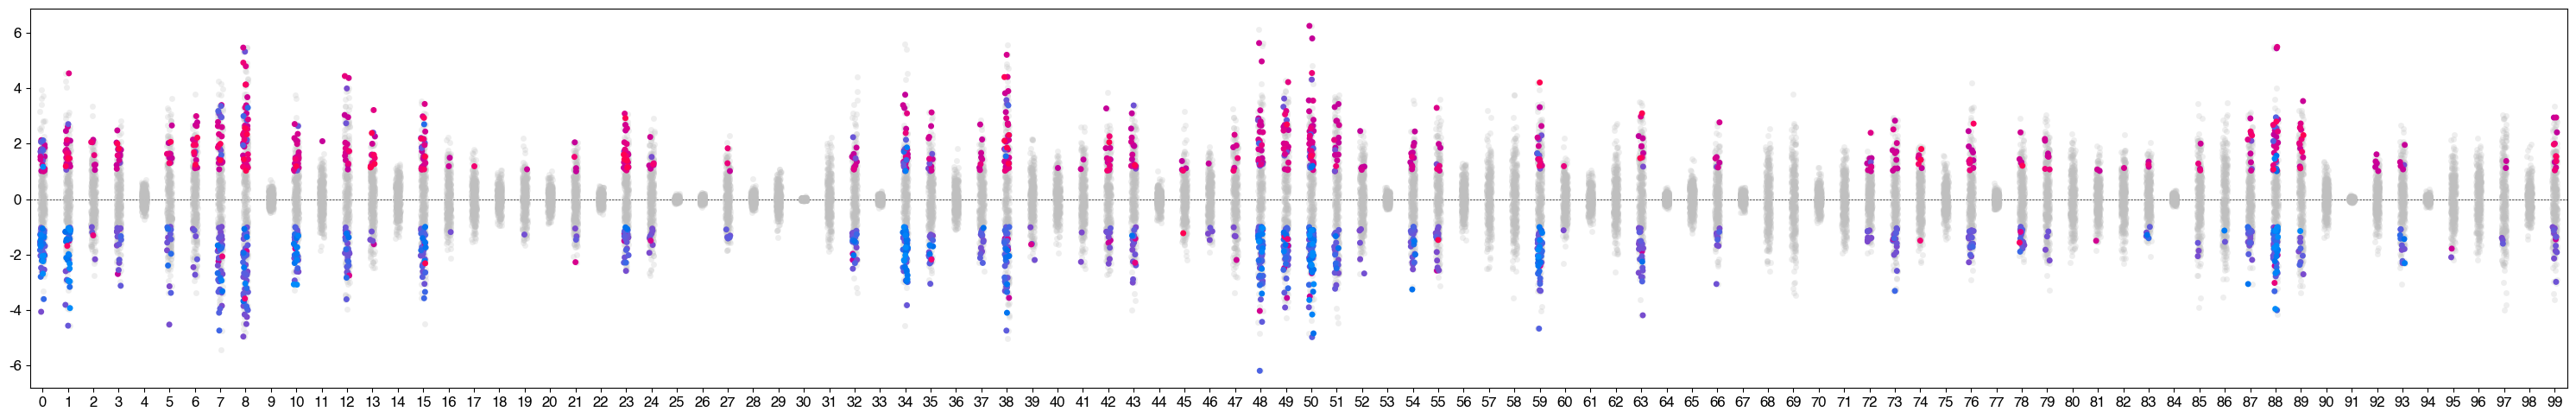

In [18]:
sys.path.append('/data1/normantm/eli/software')
from colors import red_blue
np.random.seed(42)
plt.figure(figsize = (30,5))
sns.stripplot(data = program_mtx_plot.dropna(), x = 'program', y = 'attr_score', alpha = 0.25, color = '#bfbfbf')
sns.stripplot(program_mtx_plot.query("(attr_score < -1 or attr_score > 1) and (score > 0.5 or score < -0.5)").sort_values('abs_score'), x = 'program', y = 'attr_score', hue = 'score', palette = red_blue, legend = None)
plt.axhline(0, color = '#000000', linestyle = '--', linewidth = 0.5)
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
# plt.savefig("plots/7d_crispra_comparison.png", dpi = 300)
plt.show()

### 7f triples: CREB3L3 program residual + attribution score correlation

In [3]:
condition_map = {
    '094': 'CREB3L3',
    '095': 'EGR3',
    '097': 'IRF4',
    '099': 'FOSB_SOX18',
    '100': 'CREB3L3_FOSB_SOX18',
    '101': 'EGR3_FOSB_SOX18',
    '102': 'IRF4_FOSB_SOX18',
}
dfs = []
for file in os.scandir('/data1/normantm/eli/T7/202511_RPE1_dg50/models/genelevel_clustered/triples/triples_edge_lfc'):
    df_target = pd.read_csv(file.path)[['gene_name', 'logFC']].drop_duplicates('gene_name')
    cem_number = file.name.split('-dge')[0].split('_')[-1]
    if cem_number in condition_map.keys():
        df_target['guide_target'] = cem_number
        dfs.append(df_target)
df_all = pd.concat(dfs, axis = 0)
df_all['guide_target'] = df_all.guide_target.map(condition_map)
df_lfc_edge = df_all.pivot(index = 'guide_target', columns = 'gene_name', values = 'logFC')

In [4]:
from tqdm import trange
pmtxs = []
for i in trange(100):
    df_prgm = map_attribution(i, z_prgm=False, plot = False)
    df_prgm['program_id'] = i
    pmtxs.append(df_prgm.loc['FOSB_SOX18'])
df_programs = pd.concat(pmtxs, axis = 1).T.set_index('program_id')
df_programs.index = df_programs.index.astype(int)

100%|██████████| 100/100 [01:06<00:00,  1.50it/s]


In [5]:
program_enrichment = pd.read_csv("/data1/normantm/eli/T7/202511_RPE1_dg50/models/genelevel_clustered/triples/interaction_program_amd_pops_fisher_enrichment_results (3).csv")
program_enrichment['logq'] = -np.log10(program_enrichment.pval_adj)
program_enrichment['odds_ratio'] = np.clip(program_enrichment.odds_ratio, 1, 5)
program_enrichment['logq'] = np.clip(program_enrichment.logq, 0, 5)

In [6]:
program_features = pd.read_csv("/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/260414_gex_raw_100_prgm_features.csv")
df_scores = pd.DataFrame(index = df_lfc_edge.index, columns = range(100))
for i in program_features.program_id.unique():
    df_features = program_features.query("program_id == @i")
    overlap_genes = np.intersect1d(df_features.feature, df_lfc_edge.columns)
    df_expr = df_lfc_edge[overlap_genes]
    weights = df_features.set_index('feature').loc[overlap_genes].weight
    df_scores[i] = df_expr.mul(weights).sum(axis =1)

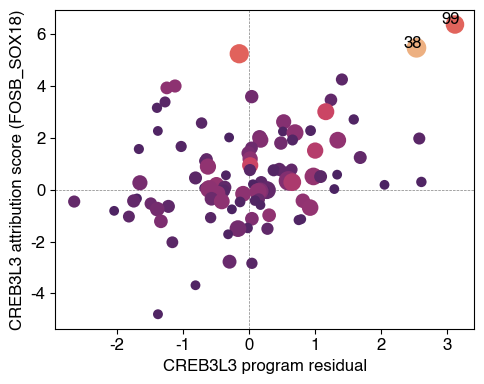

PearsonRResult(statistic=np.float64(0.3460399014115333), pvalue=np.float64(0.0004210933616737352))

In [7]:
from scipy.stats import pearsonr

creb_scores = df_scores.loc['CREB3L3_FOSB_SOX18'] - np.sqrt(2) ** -1 * (df_scores.loc['CREB3L3'] + df_scores.loc['FOSB_SOX18'])
df_creb_attr = df_programs['CREB3L3'].sort_values(ascending = False).to_frame('attr')
plt.figure(figsize=(5,4))
sns.scatterplot(df_creb_attr.join(creb_scores.to_frame('resid')).join(program_enrichment.set_index('program_id')), x = 'resid', y = 'attr', edgecolor = 'none', hue = 'logq', size = 'odds_ratio', palette = 'flare_r', legend = None, sizes = (50,200))
plt.axvline(0, color = 'grey', linestyle = '--', zorder = 0, linewidth = 0.5)
plt.axhline(0, color = 'grey', linestyle = '--', zorder = 0, linewidth = 0.5)
plt.xlabel("CREB3L3 program residual")
plt.ylabel("CREB3L3 attribution score (FOSB_SOX18)")
for idx, row in df_creb_attr.join(creb_scores.to_frame('resid')).iterrows():
    if idx in [99, 38]:
        plt.text(row['resid'] - 0.2, row['attr'], idx, color = 'k')
plt.tight_layout()
# plt.savefig('plots/7f_creb3l3_resid_attr.pdf')
plt.show()

pearsonr(df_creb_attr.sort_index().attr, creb_scores)

2026-09-28 11:34:55 - INFO - maxp pruned
2026-09-28 11:34:55 - INFO - cmap pruned
2026-09-28 11:34:55 - INFO - post pruned
2026-09-28 11:34:55 - INFO - FFTM dropped
2026-09-28 11:34:55 - INFO - GPOS pruned
2026-09-28 11:34:55 - INFO - GSUB pruned
2026-09-28 11:34:55 - INFO - glyf pruned
2026-09-28 11:34:55 - INFO - Added gid0 to subset
2026-09-28 11:34:55 - INFO - Added first four glyphs to subset
2026-09-28 11:34:55 - INFO - Closing glyph list over 'GSUB': 39 glyphs before
2026-09-28 11:34:55 - INFO - Glyph names: ['.notdef', '.null', 'B', 'E', 'F', 'G', 'O', 'R', 'S', 'X', 'a', 'b', 'c', 'd', 'e', 'eight', 'four', 'g', 'hyphen', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'r', 's', 'space', 't', 'three', 'two', 'u', 'underscore', 'uni0008', 'zero']
2026-09-28 11:34:55 - INFO - Glyph IDs:   [0, 1, 2, 3, 5, 13, 14, 18, 21, 22, 23, 24, 25, 29, 39, 42, 43, 44, 52, 55, 56, 61, 68, 70, 71, 72, 73, 74, 76, 78, 81, 82, 83, 84, 85, 87, 88, 89, 90]
2026-

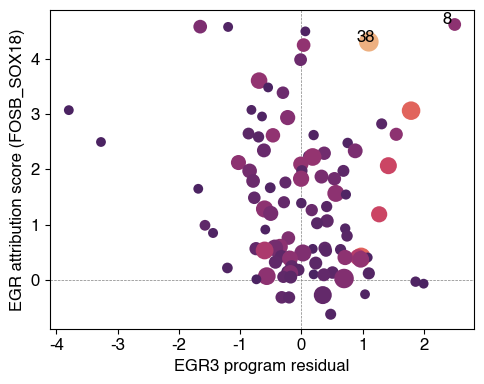

In [9]:
from scipy.stats import pearsonr

egr_scores = df_scores.loc['EGR3_FOSB_SOX18'] - np.sqrt(2) ** -1 * (df_scores.loc['EGR3'] + df_scores.loc['FOSB_SOX18'])
df_egr_attr = df_programs['EGR'].sort_values(ascending = False).to_frame('attr')
plt.figure(figsize=(5,4))
sns.scatterplot(df_egr_attr.join(egr_scores.to_frame('resid')).join(program_enrichment.set_index('program_id')), x = 'resid', y = 'attr', edgecolor = 'none', hue = 'logq', size = 'odds_ratio', palette = 'flare_r', legend = None, sizes = (50,200))
plt.axvline(0, color = 'grey', linestyle = '--', zorder = 0, linewidth = 0.5)
plt.axhline(0, color = 'grey', linestyle = '--', zorder = 0, linewidth = 0.5)
plt.xlabel("EGR3 program residual")
plt.ylabel("EGR attribution score (FOSB_SOX18)")
for idx, row in df_egr_attr.join(egr_scores.to_frame('resid')).iterrows():
    if idx in [8, 38]:
        plt.text(row['resid'] - 0.2, row['attr'], idx, color = 'k')
plt.tight_layout()
plt.savefig('plots/S7a_egr3_resid_attr.pdf')
plt.show()

2026-09-28 11:35:07 - INFO - maxp pruned
2026-09-28 11:35:07 - INFO - cmap pruned
2026-09-28 11:35:07 - INFO - post pruned
2026-09-28 11:35:07 - INFO - FFTM dropped
2026-09-28 11:35:07 - INFO - GPOS pruned
2026-09-28 11:35:07 - INFO - GSUB pruned
2026-09-28 11:35:07 - INFO - glyf pruned
2026-09-28 11:35:07 - INFO - Added gid0 to subset
2026-09-28 11:35:07 - INFO - Added first four glyphs to subset
2026-09-28 11:35:07 - INFO - Closing glyph list over 'GSUB': 39 glyphs before
2026-09-28 11:35:07 - INFO - Glyph names: ['.notdef', '.null', 'B', 'F', 'I', 'O', 'R', 'S', 'X', 'a', 'b', 'c', 'd', 'e', 'eight', 'four', 'g', 'hyphen', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'r', 's', 'six', 'space', 't', 'three', 'two', 'u', 'underscore', 'uni0008', 'zero']
2026-09-28 11:35:07 - INFO - Glyph IDs:   [0, 1, 2, 3, 5, 13, 14, 18, 21, 22, 23, 24, 25, 27, 29, 39, 43, 46, 52, 55, 56, 61, 68, 70, 71, 72, 73, 74, 76, 78, 81, 82, 83, 84, 85, 87, 88, 89, 90]
202

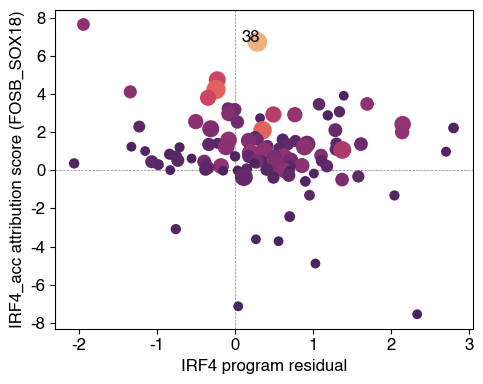

In [11]:
from scipy.stats import pearsonr

irf_scores = df_scores.loc['IRF4_FOSB_SOX18'] - np.sqrt(2) ** -1 * (df_scores.loc['IRF4'] + df_scores.loc['FOSB_SOX18'])
df_irf_attr = df_programs['IRF4_res_acc'].sort_values(ascending = False).to_frame('attr')
plt.figure(figsize=(5,4))
sns.scatterplot(df_irf_attr.join(irf_scores.to_frame('resid')).join(program_enrichment.set_index('program_id')), x = 'resid', y = 'attr', edgecolor = 'none', hue = 'logq', size = 'odds_ratio', palette = 'flare_r', legend = None, sizes = (50,200))
plt.axvline(0, color = 'grey', linestyle = '--', zorder = 0, linewidth = 0.5)
plt.axhline(0, color = 'grey', linestyle = '--', zorder = 0, linewidth = 0.5)
plt.xlabel("IRF4 program residual")
plt.ylabel("IRF4_acc attribution score (FOSB_SOX18)")
for idx, row in df_irf_attr.join(irf_scores.to_frame('resid')).iterrows():
    if idx in [38]:
        plt.text(row['resid'] - 0.2, row['attr'], idx, color = 'k')
plt.tight_layout()
plt.savefig('plots/S7b_irf4_resid_attr.pdf')
plt.show()

### 7g program heatmaps

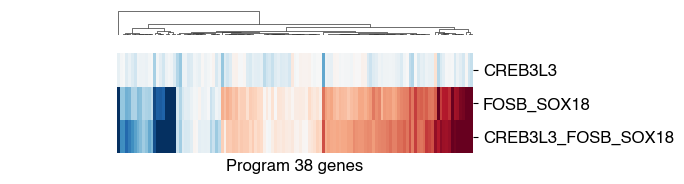

In [12]:
df38 = df_lfc_edge.filter(items = program_features.query("program_id == 38").feature.unique()).dropna(axis = 1)
cg = sns.clustermap(df38.loc[['CREB3L3', 'FOSB_SOX18', 'CREB3L3_FOSB_SOX18']], cmap = 'RdBu_r', vmin = -2, vmax = 2, center = 0, metric = 'euclidean', robust = True, figsize=(7, 2), row_cluster=False, xticklabels = 0, yticklabels = 1, cbar_pos = None)
plt.xlabel("Program 38 genes")
plt.ylabel('')
plt.tight_layout()
# plt.savefig("plots/7g_CREB3L3_p38.pdf")
plt.show()

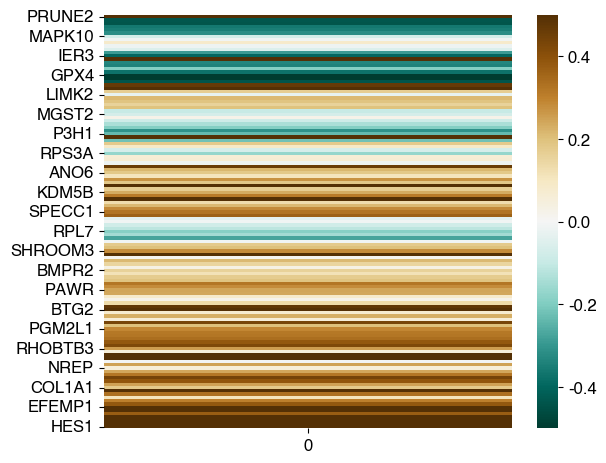

In [13]:
df38 = df_lfc_edge.filter(items = programs_diff.query("program_id == 38").feature.unique()).dropna(axis = 1)
df_resid = df38.loc['CREB3L3_FOSB_SOX18'] - (df38.loc['CREB3L3'] + df38.loc['FOSB_SOX18'])
sns.heatmap(df_resid.iloc[cg.dendrogram_col.reordered_ind].T.to_frame(), vmin = -0.5, vmax = 0.5, cmap = 'BrBG_r')
plt.tight_layout()
# plt.savefig("plots/7g_CREB3L3_p38_resid_bar.pdf")

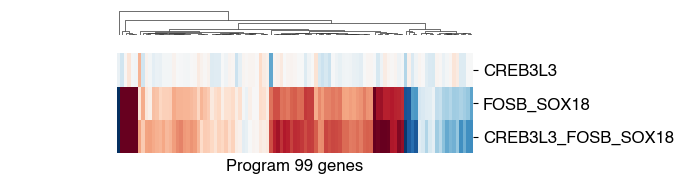

In [14]:
df99 = df_lfc_edge.filter(items = program_features.query("program_id == 99").feature.unique()).dropna(axis = 1)
cg = sns.clustermap(df99.loc[['CREB3L3', 'FOSB_SOX18', 'CREB3L3_FOSB_SOX18']], cmap = 'RdBu_r', vmin = -2, vmax = 2, center = 0, metric = 'euclidean', robust = True, figsize=(7, 2), row_cluster=False, xticklabels = 0, yticklabels = 1, cbar_pos = None)
plt.xlabel("Program 99 genes")
plt.ylabel('')
plt.tight_layout()
# plt.savefig("plots/7g_CREB3L3_p99.pdf")
plt.show()

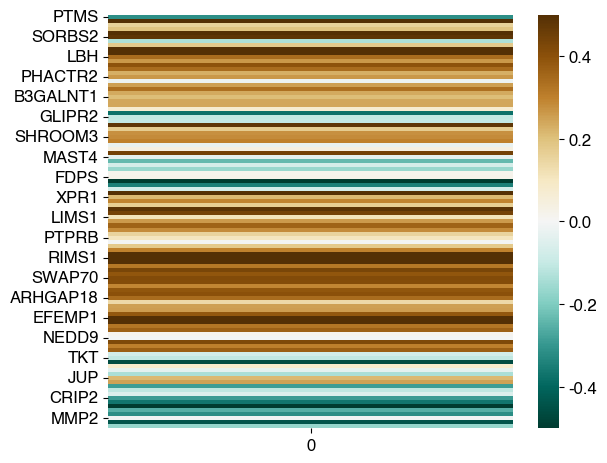

In [15]:
df_resid = df99.loc['CREB3L3_FOSB_SOX18'] - (df99.loc['CREB3L3'] + df99.loc['FOSB_SOX18'])
sns.heatmap(df_resid.iloc[cg.dendrogram_col.reordered_ind].T.to_frame(), vmin = -0.5, vmax = 0.5, cmap = 'BrBG_r')
plt.tight_layout()
# plt.savefig("plots/7g_CREB3L3_p99_resid_bar.pdf")
plt.show()

### 7h BEST1 / CP gene-level residuals

In [12]:
def get_resid_df(single):

    triple = f"{single}_FOSB_SOX18"
    df_resid = df_lfc_edge.loc[triple] - (df_lfc_edge.loc[single] + df_lfc_edge.loc['FOSB_SOX18'])
    df_resid = df_resid.to_frame().reset_index().rename(columns = {0: 'resid'}).drop_duplicates('gene_name', keep = 'first')
    df_resid[single] = df_resid.gene_name.map(lambda i: df_lfc_edge.loc[single, i].item())
    df_resid['FOSB_SOX18'] = df_resid.gene_name.map(lambda i: df_lfc_edge.loc['FOSB_SOX18', i].item())
    df_resid[triple] = df_resid.gene_name.map(lambda i: df_lfc_edge.loc[triple, i].item())
    df_resid.columns = ['gene', 'resid', 'single', 'double', 'triple']
    df_resid['single_id'] = single
    return df_resid

mono_genes = [
    'HSPG2', 'LEPR', 'ABCA4', 'DRAM2', 'NAXE', 'SLC19A2', 'FASLG', 'HMCN1',
    'CDC73', 'CFH', 'CFHR3', 'RD3', 'NLRP3', 'CXCL12', 'HK1', 'PTEN',
    'FAS', 'RBP4', 'COL17A1', 'ARMS2', 'TNNI2', 'PTH', 'BEST1', 'ROM1',
    'LRP5', 'CCND1', 'CAPN5', 'FZD4', 'PTHLH', 'IGF1', 'GJB2', 'FOXO1',
    'COL4A1', 'ANG', 'ZFYVE26', 'FBLN5', 'DLL4', 'IGF1R', 'ABCC6', 'XYLT1',
    'MMP2', 'SERPINF1', 'NLRP1', 'PITPNM3', 'TP53', 'GUCY2D', 'CCL2', 'ITGB3',
    'XYLT2', 'GH1', 'COG1', 'PRCD', 'RAB31', 'PIEZO2', 'RAX2', 'INSR',
    'APOE', 'ERCC2', 'EFEMP1', 'ALMS1', 'CXCR4', 'COL4A3', 'AGXT', 'SOD1',
    'C21orf2', 'TIMP3', 'VHL', 'CX3CR1', 'CTNNB1', 'CCR5', 'MAPKAPK3', 'ATXN7',
    'IMPG2', 'CP', 'OPA1', 'PCYT1A', 'RAB28', 'PROM1', 'KDR', 'IGFBP7',
    'MFSD8', 'LRAT', 'TLR3', 'FBN2', 'PDGFRB', 'SPARC', 'ATXN1', 'TULP1',
    'PRPH2', 'VEGFA', 'ELOVL4', 'ADAT2', 'MPLKIP', 'EPO', 'LEP', 'IMPDH1',
    'NOS3', 'RP1L1', 'RP1', 'CNGB3', 'MYC', 'VLDLR', 'KCNV2', 'ENG'
]

get_resid_df('CREB3L3').query("gene.isin(@mono_genes)").sort_values('resid', ascending=False).head(50)

,gene,resid,single,double,triple,single_id
2355,CP,1.422216,0.002262,0.763002,2.187480,CREB3L3
1094,BEST1,1.080859,-0.199803,0.271544,1.152600,CREB3L3
36,ABCC6,0.974182,-0.386937,-1.025820,-0.438575,CREB3L3
581,APOE,0.798328,-0.549770,-0.371598,-0.123040,CREB3L3
191,ADAT2,0.669328,-0.321372,0.489056,0.837012,CREB3L3
10522,PTHLH,0.625579,0.003431,1.640680,2.269690,CREB3L3
3219,EFEMP1,0.600041,-0.329411,1.676910,1.947540,CREB3L3
6395,HMCN1,0.564968,-0.589258,1.047980,1.023690,CREB3L3
947,ATXN7,0.480146,-0.175124,0.303542,0.608564,CREB3L3
6664,IGF1R,0.469346,-0.220934,0.239727,0.488139,CREB3L3


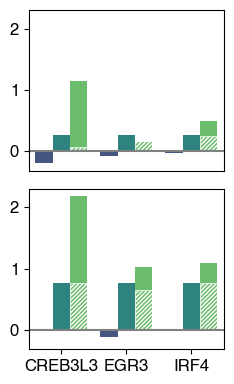

In [17]:
def plot_gene_bars(gene, ax):
    df_gene = pd.concat(get_resid_df(i).query(f"gene == '{gene}'") for i in ['CREB3L3', 'EGR3', 'IRF4'])
    df_plot = df_gene.drop(['resid', 'gene'], axis=1).melt(id_vars='single_id', var_name='condition', value_name='lfc')
    df_plot['single_id'] = pd.Categorical(df_plot.single_id, ordered=True, categories=['CREB3L3', 'EGR3', 'IRF4'])

    sns.barplot(df_plot, x='single_id', y='lfc', hue='condition', palette='viridis', legend=None, ax=ax)

    expected = {}
    for single in ['CREB3L3', 'EGR3', 'IRF4']:
        row = get_resid_df(single).query(f"gene == '{gene}'").fillna(0)
        expected[single] = row.single.item() + row.double.item()

    df_additive = df_plot.copy()
    df_additive['lfc'] = df_additive.apply(lambda df: 0 if df.condition != 'triple' else expected[df.single_id], axis=1)
    sns.barplot(df_additive, x='single_id', y='lfc', hue='condition', facecolor='none',
                edgecolor='white', linewidth=0.5, hatch='////////', legend=None, ax=ax)

    ax.axhline(0, color='grey')
    ax.set_xlabel("")
    ax.set_ylabel("")

fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(2.5, 4), sharex=True, sharey=True)
plot_gene_bars('BEST1', ax1)
plot_gene_bars('CP', ax2)
ax1.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
plt.tight_layout()
# plt.savefig('plots/5L_BEST1_CP.pdf')
plt.show()

In [14]:
import pyranges as pr

protein_coding = pr.read_gtf('/data1/normantm/eli/seq2gex/data/genome/genes.gtf').df.query("Feature == 'gene' and gene_type == 'protein_coding'").gene_name.unique()
df_hist = get_resid_df('CREB3L3').sort_values('resid', ascending=False).dropna().query("gene.isin(@protein_coding)")
df_hist['pctl'] = df_hist.resid.rank(pct=True)
df_hist.sort_values('resid', ascending=False).head(50)

,gene,resid,single,double,triple,single_id,pctl
12616,SPNS2,2.813632,-0.108362,-8.399660,-5.694390,CREB3L3,1.000000
8769,NDRG2,2.526350,-1.313700,-3.817910,-2.605260,CREB3L3,0.999911
7224,L1TD1,1.801607,-0.731871,-0.910758,0.158978,CREB3L3,0.999822
501,ANO7,1.786089,-0.711410,-1.446410,-0.371731,CREB3L3,0.999733
10187,PPL,1.770512,-1.342880,-0.167976,0.259656,CREB3L3,0.999645
3235,EGF,1.719029,0.026978,-0.243627,1.502380,CREB3L3,0.999556
659,ARHGEF16,1.687244,-0.620314,-3.173070,-2.106140,CREB3L3,0.999467
8439,MSS51,1.568260,-0.410296,-0.987873,0.170091,CREB3L3,0.999378
6879,ITGB8,1.535190,-0.613879,0.901209,1.822520,CREB3L3,0.999289
7204,KRT5,1.500946,-0.667958,-0.319296,0.513692,CREB3L3,0.999200


In [24]:
df_hist

,gene,resid,single,double,triple,single_id,pctl
12616,SPNS2,2.813632,-0.108362,-8.399660,-5.694390,CREB3L3,1.000000
8769,NDRG2,2.526350,-1.313700,-3.817910,-2.605260,CREB3L3,0.999911
7224,L1TD1,1.801607,-0.731871,-0.910758,0.158978,CREB3L3,0.999822
501,ANO7,1.786089,-0.711410,-1.446410,-0.371731,CREB3L3,0.999733
10187,PPL,1.770512,-1.342880,-0.167976,0.259656,CREB3L3,0.999645
...,...,...,...,...,...,...,...
12194,SLC37A2,-1.474585,0.590869,-0.710184,-1.593900,CREB3L3,0.000444
10733,RAET1G,-1.729072,0.084962,-1.281740,-2.925850,CREB3L3,0.000355
12200,SLC38A3,-1.753518,-0.109742,-2.096750,-3.960010,CREB3L3,0.000267
11515,RRAD,-2.099341,-0.818379,-2.016520,-4.934240,CREB3L3,0.000178


2026-09-28 11:44:05 - INFO - maxp pruned
2026-09-28 11:44:05 - INFO - cmap pruned
2026-09-28 11:44:05 - INFO - post pruned
2026-09-28 11:44:05 - INFO - FFTM dropped
2026-09-28 11:44:05 - INFO - GPOS pruned
2026-09-28 11:44:05 - INFO - GSUB pruned
2026-09-28 11:44:05 - INFO - glyf pruned
2026-09-28 11:44:05 - INFO - Added gid0 to subset
2026-09-28 11:44:05 - INFO - Added first four glyphs to subset
2026-09-28 11:44:05 - INFO - Closing glyph list over 'GSUB': 33 glyphs before
2026-09-28 11:44:05 - INFO - Glyph names: ['.notdef', '.null', 'B', 'C', 'E', 'G', 'L', 'O', 'R', 'a', 'b', 'd', 'e', 'eight', 'four', 'hyphen', 'i', 'l', 'n', 'nonmarkingreturn', 'one', 'parenleft', 'parenright', 'r', 's', 'six', 'space', 'three', 'two', 'u', 'uni0008', 'v', 'zero']
2026-09-28 11:44:05 - INFO - Glyph IDs:   [0, 1, 2, 3, 5, 13, 14, 18, 21, 22, 23, 24, 25, 27, 29, 39, 40, 42, 44, 49, 52, 55, 70, 71, 73, 74, 78, 81, 83, 87, 88, 90, 91]
2026-09-28 11:44:05 - INFO - Closed glyph list over 'GSUB': 33 gly

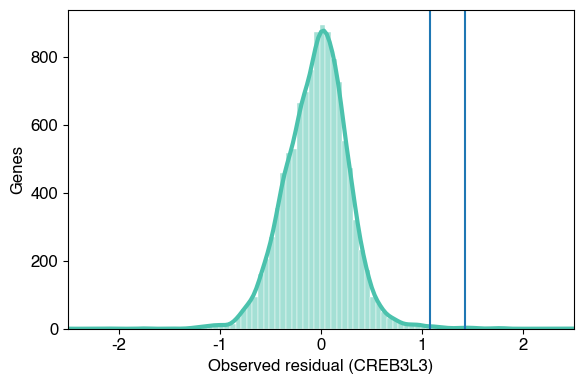

In [17]:
plt.figure(figsize = (6,4))
sns.histplot(df_hist.resid, bins = 100, edgecolor = 'white', color = '#4bc2ad', kde = True, line_kws={'linewidth': 3})
plt.axvline(df_hist.set_index('gene').loc['BEST1', 'resid'])
plt.axvline(df_hist.set_index('gene').loc['CP', 'resid'])
plt.xlim(-2.5, 2.5)
plt.xlabel("Observed residual (CREB3L3)")
plt.ylabel("Genes")
plt.tight_layout()
plt.savefig("plots/S7c_BEST1_CP_hist.pdf")
plt.show()